# 02 Behavior Variable EDA

## 1. Data

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", context="notebook")

# ------------------ paths ------------------
ROOT = Path.cwd().resolve().parent
RAW_PATH = ROOT / "data" / "raw" / "YRBS_2007.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_combined_processed.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
SUM_DIR = ROOT / "outputs" / "summary"
REF_DIR = ROOT / "references"

for p in [FIG_DIR, TAB_DIR, SUM_DIR, REF_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ------------------ formal behavior variable ------------------
BEHAVIOR_VAR = "SadOrHopeless"
BEHAVIOR_P0 = 0.30

# ------------------ read data ------------------
raw = pd.read_csv(RAW_PATH)
processed = pd.read_csv(PROCESSED_PATH)

print("Raw data shape:", raw.shape)
print("Processed data shape:", processed.shape)

Raw data shape: (14041, 103)
Processed data shape: (14041, 10)


In [2]:
# copy
behavior = processed[[BEHAVIOR_VAR, "sad_binary"]].copy()
behavior_valid = behavior.dropna(subset=["sad_binary"]).copy()

## 2. Behavior Variable EDA

### 2.1 Original code

,raw_code,count,proportion
0,Failure (2),9692,0.690
1,Success (1),4153,0.296
2,Missing or invalid,196,0.014


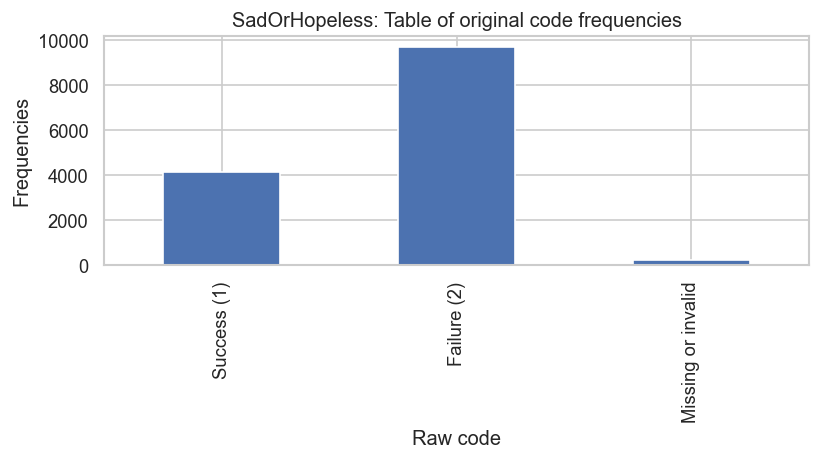

In [3]:
# ----------表----------
behavior_raw_freq = (
    raw[BEHAVIOR_VAR]
    .value_counts(dropna=False)
    .rename_axis("raw_code")
    .reset_index(name="count")
)

behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].astype("object")
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].where(
    behavior_raw_freq["raw_code"].notna(), "Missing or invalid"
)

# 只把 1, 2 轉成可讀標籤
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].replace({
    1: "Success (1)",
    2: "Failure (2)"
})

behavior_raw_freq["proportion"] = (
    behavior_raw_freq["count"] / behavior_raw_freq["count"].sum()
).round(3)

display(behavior_raw_freq)

# ----------圖表----------
raw_plot_counts = (
    raw[BEHAVIOR_VAR]
    .astype("object")
    .where(raw[BEHAVIOR_VAR].notna(), "Missing or invalid")
    .replace({1: "Success (1)", 2: "Failure (2)"})
    .value_counts(dropna=False)
    .reindex(["Success (1)", "Failure (2)", "Missing or invalid"], fill_value=0)
)

plt.figure(figsize=(7, 4))
raw_plot_counts.plot(kind="bar")
plt.title("SadOrHopeless: Table of original code frequencies")
plt.xlabel("Raw code")
plt.ylabel("Frequencies")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_original_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** The original responses are concentrated in codes 1 and 2, with a smaller number of missing values.

### 2.2 Binary recoding

,category,count,proportion
0,Failure (0),9692,0.700036
1,Success (1),4153,0.299964


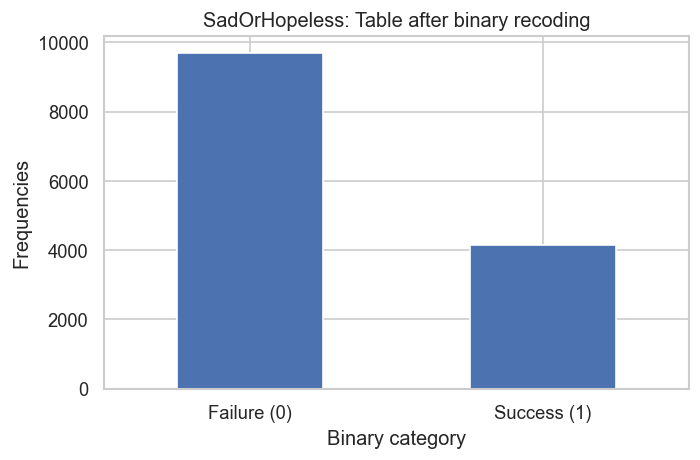

In [4]:
# ----------表----------
behavior_binary_summary = pd.DataFrame({
    "category": ["Failure (0)", "Success (1)"],
    "count": [
        int((behavior_valid["sad_binary"] == 0).sum()),
        int((behavior_valid["sad_binary"] == 1).sum())
    ]
})

behavior_binary_summary["proportion"] = (
    behavior_binary_summary["count"] / behavior_binary_summary["count"].sum()
)

display(behavior_binary_summary)

# ----------圖表----------
binary_plot_counts = behavior_valid["sad_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
binary_plot_counts.plot(kind="bar")
plt.title("SadOrHopeless: Table after binary recoding")
plt.xlabel("Binary category")
plt.ylabel("Frequencies")
plt.xticks([0, 1], ["Failure (0)", "Success (1)"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_binary_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** After binary recoding, the Failure (0) group is more common than the Success (1) group. This suggests that the proportion of students reporting SadOrHopeless is below 0.50, but it may still be above or below the benchmark proportion of 0.30, so formal inference is needed.